In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

C:\Users\admin\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
df = pd.read_csv(r'../pre-calculated_data/all_rgi_mags_strict.tsv',sep='\t',usecols=[0,1,6,9,10,11,15,16,17,19,21],names=['mag','gene','cutoff','arg','identity','aro','drug_class','mechanism','aro_family','seq','coverage'])
df = df[df['cutoff']=='Strict']
df

,mag,gene,cutoff,arg,identity,aro,drug_class,mechanism,aro_family,seq,coverage
1,cpsnj01_SemiBin_0,cpsnj01_contig_38134_polypolish_182 # 204873 #...,Strict,adeF,43.7,3000777,fluoroquinolone antibiotic; tetracycline antib...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,MLKTFIERPVLSTVVSIILTLLGLLSLYSLPITLFPDIAPPTVQVT...,98.96
2,cpsnj01_SemiBin_0,cpsnj01_contig_5592_polypolish_436 # 463489 # ...,Strict,adeF,43.61,3000777,fluoroquinolone antibiotic; tetracycline antib...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,MSEFFIRRPIFAMVLSILMVILGLLVLRGIPISQYPEITPPMVQVN...,99.53
3,cpsnj01_SemiBin_0,cpsnj01_contig_14889_polypolish_285 # 324550 #...,Strict,vanT gene in vanG cluster,30.42,3002972,glycopeptide antibiotic,antibiotic target alteration,glycopeptide resistance gene cluster; vanT,MNYHITDIASAINANWLQAGIDGHVSHLLIDSRKLVFPGGTLFFAI...,115.73
5,cpsnj01_SemiBin_10,cpsnj01_contig_38914_polypolish_20 # 14857 # 1...,Strict,vanT gene in vanG cluster,34.66,3002972,glycopeptide antibiotic,antibiotic target alteration,glycopeptide resistance gene cluster; vanT,MVRSTIARVDLEALRHNFSAIRTFLQQGARDSGNSEAPTILAVVKA...,53.79
6,cpsnj01_SemiBin_10,cpsnj01_contig_956_polypolish_504 # 524644 # 5...,Strict,adeF,45.5,3000777,fluoroquinolone antibiotic; tetracycline antib...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,MARFFVNRPIVAMVISIITVLLGVVALSGLPVSQYPEIVPPMIQVT...,100.09
...,...,...,...,...,...,...,...,...,...,...,...
18348,snj11_SemiBin_97,snj11_contig_3617_polypolish_3 # 1359 # 2522 #...,Strict,vanT gene in vanG cluster,34.93,3002972,glycopeptide antibiotic,antibiotic target alteration,glycopeptide resistance gene cluster; vanT,MIRCTSARVDLTAIQANYRALTAYLAREADLNRQAAAGPATPPGIL...,54.35
18350,snj11_SemiBin_98,snj11_contig_12531_polypolish_899 # 1057666 # ...,Strict,vanT gene in vanG cluster,35.38,3002972,glycopeptide antibiotic,antibiotic target alteration,glycopeptide resistance gene cluster; vanT,MVRCTTARVDLAALASNYANIVTYFSGEAGLNRAAGRGPVVAPGII...,53.79
18352,snj11_SemiBin_99,snj11_contig_17239_polypolish_288 # 290269 # 2...,Strict,vanT gene in vanG cluster,34.22,3002972,glycopeptide antibiotic,antibiotic target alteration,glycopeptide resistance gene cluster; vanT,MLLPAESVADHAAAAGRPTRIRIDLDALTHNVQALRAHAGVPVMGI...,56.04
18354,snj11_SemiBin_9,snj11_contig_27894_polypolish_98 # 124908 # 12...,Strict,vanT gene in vanG cluster,31.85,3002972,glycopeptide antibiotic,antibiotic target alteration,glycopeptide resistance gene cluster; vanT,MIRPTVARIDLSAIRQNFHSIAQFLRTSTSEVRPGSEQGLTPGIIA...,53.51


In [4]:
df['identity'] = pd.to_numeric(df['identity'], errors='coerce')
df['coverage'] = pd.to_numeric(df['coverage'], errors='coerce')
mag_filter = df[(df['identity']>80) & (df['coverage']>90)]
mag_filter

,mag,gene,cutoff,arg,identity,aro,drug_class,mechanism,aro_family,seq,coverage
449,cpsnj03_SemiBin_14,cpsnj03_contig_484_polypolish_243 # 234053 # 2...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,82.64,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MPTIQQLVRQGRSRPREKTKAPALKGSPQRRGVCTRVYTTTPKKPN...,100.00
468,cpsnj03_SemiBin_18,cpsnj03_contig_24068_polypolish_420 # 471869 #...,Strict,rsmA,83.05,3005069,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,MLILTRRVGETVMIGDDVTVTVLGVKGNQVRIGVNAPKSVAVHREE...,113.11
537,cpsnj03_SemiBin_36,cpsnj03_contig_4622_polypolish_246 # 237203 # ...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,86.99,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MPTIQQLVRQGRSSKSTKTKTPALKGSPQRRGVCTRVYTTTPKKPN...,99.19
740,cpsnj04_SemiBin_13,cpsnj04_contig_8_polypolish_469 # 488668 # 488...,Strict,rsmA,83.05,3005069,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,MLILTRRVGETVMIGDDVTVTVLGVKGNQVRIGVNAPKSVAVHREE...,113.11
901,cpsnj04_SemiBin_48,cpsnj04_contig_81817_polypolish_54 # 38621 # 3...,Strict,rsmA,85.96,3005069,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,MLILTRRVGETLMIGDAITVTVLGVKGNQVRLGVNAPKEVAVHREE...,108.20
...,...,...,...,...,...,...,...,...,...,...,...
17689,snj20_SemiBin_148,snj20_contig_7095_polypolish_208 # 184157 # 18...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,86.99,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MPTIQQLVRQGRSSKSTKTKTPALKGSPQRRGVCTRVYTTTPKKPN...,99.19
17856,snj20_SemiBin_58,snj20_contig_44448_polypolish_96 # 69795 # 702...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,86.18,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MHCPLTGVPSPVYGGRARLAQPTTFRRPWCRRSDQTNEVSFVPTIQ...,132.26
17865,snj20_SemiBin_60,snj20_contig_14416_polypolish_62 # 51252 # 526...,Strict,Streptomyces venezuelae rox,80.38,3007209,rifamycin antibiotic,antibiotic inactivation,rifampin monooxygenase,MFDVIIAGGGPTGMMLAGELRLHGVRVLVLEKEAEPTKVVRSLGLH...,99.79
18268,snj11_SemiBin_68,snj11_contig_15346_polypolish_142 # 126606 # 1...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,82.11,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MPTISQLVRKGRESKSDKTKTPALKGAPQRRGVCTRVYTHTPKKPN...,100.00


In [5]:
meta = pd.read_csv(r'../pre-calculated_data/sample_bins_info_mimag_gc.tsv',sep='\t')
meta

,Sample,Mag ID,nbps,Nr contigs,N50,L50,Completeness,Contamination,Quality,Drep_95,...,Total tRNA,Unique tRNA,GTDB,MIMAG,SGB,ARO,Drug Class,Resistance Mechanism,AMR Gene Family,GC content
0,cpsnj01,cpsnj01_SemiBin_0,5051260,10,748488,3,99.97,0.22,High quality,T,...,41,20,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,T,34_0,3000777;3002972,fluoroquinolone antibiotic; tetracycline antib...,"antibiotic target alteration,antibiotic efflux","glycopeptide resistance gene cluster; vanT,res...",0.467241
1,cpsnj01,cpsnj01_SemiBin_10,6169334,14,733099,3,91.13,2.78,High quality,T,...,48,20,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,T,1187_1,3002972;3000777,fluoroquinolone antibiotic; tetracycline antib...,"antibiotic target alteration,antibiotic efflux","glycopeptide resistance gene cluster; vanT,res...",0.657316
2,cpsnj01,cpsnj01_SemiBin_110,4445810,30,172645,9,50.92,1.11,Medium quality,T,...,19,12,NaN,F,1384_0,NaN,NaN,NaN,NaN,0.662246
3,cpsnj01,cpsnj01_SemiBin_112,4872754,55,117499,16,57.39,6.50,Medium quality,T,...,43,17,d__Bacteria;p__Gemmatimonadota;c__Gemmatimonad...,F,601_0,3003724,glycopeptide antibiotic,antibiotic target alteration,vanW; glycopeptide resistance gene cluster,0.657481
4,cpsnj01,cpsnj01_SemiBin_115,3892740,35,144473,10,57.02,0.00,Medium quality,F,...,33,16,NaN,F,57_1,NaN,NaN,NaN,NaN,0.461886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7944,snj20,snj20_SemiBin_95,2549221,17,227894,4,70.43,9.78,Medium quality,T,...,39,18,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,F,2438_0,3000777,fluoroquinolone antibiotic; tetracycline antib...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,0.638630
7945,snj20,snj20_SemiBin_963,4456061,25,212925,8,65.69,9.61,Medium quality,T,...,27,15,d__Bacteria;p__Acidobacteriota;c__Vicinamibact...,F,1428_2,NaN,NaN,NaN,NaN,0.657995
7946,snj20,snj20_SemiBin_96,4999939,32,195695,7,59.11,5.13,Medium quality,F,...,34,16,d__Bacteria;p__Acidobacteriota;c__Vicinamibact...,F,1393_1,NaN,NaN,NaN,NaN,0.688068
7947,snj20,snj20_SemiBin_97,1895537,17,108637,4,53.23,4.62,Medium quality,T,...,42,18,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,F,2466_0,NaN,NaN,NaN,NaN,0.674686


In [6]:
merged = pd.merge(mag_filter,meta,left_on='mag',right_on='Mag ID',how='inner')
merged

,mag,gene,cutoff,arg,identity,aro,drug_class,mechanism,aro_family,seq,...,Total tRNA,Unique tRNA,GTDB,MIMAG,SGB,ARO,Drug Class,Resistance Mechanism,AMR Gene Family,GC content
0,cpsnj03_SemiBin_14,cpsnj03_contig_484_polypolish_243 # 234053 # 2...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,82.64,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MPTIQQLVRQGRSRPREKTKAPALKGSPQRRGVCTRVYTTTPKKPN...,...,46,19,d__Bacteria;p__Actinomycetota;c__UBA4738;o__UB...,F,2724_5,3002972;3003395,"glycopeptide antibiotic,aminoglycoside antibiotic",antibiotic target alteration,"glycopeptide resistance gene cluster; vanT,ant...",0.706121
1,cpsnj03_SemiBin_18,cpsnj03_contig_24068_polypolish_420 # 471869 #...,Strict,rsmA,83.05,3005069,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,MLILTRRVGETVMIGDDVTVTVLGVKGNQVRIGVNAPKSVAVHREE...,...,50,20,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,F,2036_1,3000777;3005069,fluoroquinolone antibiotic; tetracycline antib...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,0.680293
2,cpsnj03_SemiBin_36,cpsnj03_contig_4622_polypolish_246 # 237203 # ...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,86.99,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MPTIQQLVRQGRSSKSTKTKTPALKGSPQRRGVCTRVYTTTPKKPN...,...,39,19,d__Bacteria;p__Actinomycetota;c__Acidimicrobii...,F,2735_2,3002972;3003395,"glycopeptide antibiotic,aminoglycoside antibiotic",antibiotic target alteration,"glycopeptide resistance gene cluster; vanT,ant...",0.694048
3,cpsnj04_SemiBin_13,cpsnj04_contig_8_polypolish_469 # 488668 # 488...,Strict,rsmA,83.05,3005069,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,MLILTRRVGETVMIGDDVTVTVLGVKGNQVRIGVNAPKSVAVHREE...,...,54,20,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,F,2036_1,3000777;3005069,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,0.679432
4,cpsnj04_SemiBin_48,cpsnj04_contig_81817_polypolish_54 # 38621 # 3...,Strict,rsmA,85.96,3005069,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,MLILTRRVGETLMIGDAITVTVLGVKGNQVRLGVNAPKEVAVHREE...,...,52,20,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,F,788_3,3005069;3007015;3004107,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic target alteration; antibiotic efflu...,ATP-binding cassette (ABC) antibiotic efflux p...,0.633799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,snj20_SemiBin_148,snj20_contig_7095_polypolish_208 # 184157 # 18...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,86.99,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MPTIQQLVRQGRSSKSTKTKTPALKGSPQRRGVCTRVYTTTPKKPN...,...,49,18,d__Bacteria;p__Actinomycetota;c__Acidimicrobii...,F,2735_2,3002972;3003395,"glycopeptide antibiotic,aminoglycoside antibiotic",antibiotic target alteration,"glycopeptide resistance gene cluster; vanT,ant...",0.689237
129,snj20_SemiBin_58,snj20_contig_44448_polypolish_96 # 69795 # 702...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,86.18,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MHCPLTGVPSPVYGGRARLAQPTTFRRPWCRRSDQTNEVSFVPTIQ...,...,35,18,d__Bacteria;p__Actinomycetota;c__Acidimicrobii...,F,2732_0,3002972;3003395,"glycopeptide antibiotic,aminoglycoside antibiotic",antibiotic target alteration,"glycopeptide resistance gene cluster; vanT,ant...",0.691118
130,snj20_SemiBin_60,snj20_contig_14416_polypolish_62 # 51252 # 526...,Strict,Streptomyces venezuelae rox,80.38,3007209,rifamycin antibiotic,antibiotic inactivation,rifampin monooxygenase,MFDVIIAGGGPTGMMLAGELRLHGVRVLVLEKEAEPTKVVRSLGLH...,...,63,20,d__Bacteria;p__Act

In [7]:
merged['tax'] = merged['GTDB'].str.split(';').apply(lambda x: x[3])
merged

,mag,gene,cutoff,arg,identity,aro,drug_class,mechanism,aro_family,seq,...,Unique tRNA,GTDB,MIMAG,SGB,ARO,Drug Class,Resistance Mechanism,AMR Gene Family,GC content,tax
0,cpsnj03_SemiBin_14,cpsnj03_contig_484_polypolish_243 # 234053 # 2...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,82.64,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MPTIQQLVRQGRSRPREKTKAPALKGSPQRRGVCTRVYTTTPKKPN...,...,19,d__Bacteria;p__Actinomycetota;c__UBA4738;o__UB...,F,2724_5,3002972;3003395,"glycopeptide antibiotic,aminoglycoside antibiotic",antibiotic target alteration,"glycopeptide resistance gene cluster; vanT,ant...",0.706121,o__UBA4738
1,cpsnj03_SemiBin_18,cpsnj03_contig_24068_polypolish_420 # 471869 #...,Strict,rsmA,83.05,3005069,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,MLILTRRVGETVMIGDDVTVTVLGVKGNQVRIGVNAPKSVAVHREE...,...,20,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,F,2036_1,3000777;3005069,fluoroquinolone antibiotic; tetracycline antib...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,0.680293,o__Steroidobacterales
2,cpsnj03_SemiBin_36,cpsnj03_contig_4622_polypolish_246 # 237203 # ...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,86.99,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MPTIQQLVRQGRSSKSTKTKTPALKGSPQRRGVCTRVYTTTPKKPN...,...,19,d__Bacteria;p__Actinomycetota;c__Acidimicrobii...,F,2735_2,3002972;3003395,"glycopeptide antibiotic,aminoglycoside antibiotic",antibiotic target alteration,"glycopeptide resistance gene cluster; vanT,ant...",0.694048,o__Acidimicrobiales
3,cpsnj04_SemiBin_13,cpsnj04_contig_8_polypolish_469 # 488668 # 488...,Strict,rsmA,83.05,3005069,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,MLILTRRVGETVMIGDDVTVTVLGVKGNQVRIGVNAPKSVAVHREE...,...,20,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,F,2036_1,3000777;3005069,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,0.679432,o__Steroidobacterales
4,cpsnj04_SemiBin_48,cpsnj04_contig_81817_polypolish_54 # 38621 # 3...,Strict,rsmA,85.96,3005069,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,MLILTRRVGETLMIGDAITVTVLGVKGNQVRLGVNAPKEVAVHREE...,...,20,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,F,788_3,3005069;3007015;3004107,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic target alteration; antibiotic efflu...,ATP-binding cassette (ABC) antibiotic efflux p...,0.633799,o__Pseudomonadales
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,snj20_SemiBin_148,snj20_contig_7095_polypolish_208 # 184157 # 18...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,86.99,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MPTIQQLVRQGRSSKSTKTKTPALKGSPQRRGVCTRVYTTTPKKPN...,...,18,d__Bacteria;p__Actinomycetota;c__Acidimicrobii...,F,2735_2,3002972;3003395,"glycopeptide antibiotic,aminoglycoside antibiotic",antibiotic target alteration,"glycopeptide resistance gene cluster; vanT,ant...",0.689237,o__Acidimicrobiales
129,snj20_SemiBin_58,snj20_contig_44448_polypolish_96 # 69795 # 702...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,86.18,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MHCPLTGVPSPVYGGRARLAQPTTFRRPWCRRSDQTNEVSFVPTIQ...,...,18,d__Bacteria;p__Actinomycetota;c__Acidimicrobii...,F,2732_0,3002972;3003395,"glycopeptide antibiotic,aminoglycoside antibiotic",antibiotic target alteration,"glycopeptide resistance gene cluster; vanT,ant...",0.691118,o__Acidimicrobiales
130,snj20_SemiBin_60,snj20_contig_14416_polypolish_62 # 51252 # 526...,Strict,Streptomyces venezuelae rox,80.38,3007209,rifamycin antibiotic,antibiotic inactiva

In [8]:
result = merged.groupby(['tax', 'arg']).size().reset_index(name='count')
result['count']=1
result

,tax,arg,count
0,o__Acidimicrobiales,Mycobacterium tuberculosis rpsL mutations conf...,1
1,o__Actinomycetales,vanX gene in vanO cluster,1
2,o__Burkholderiales,DfrB9,1
3,o__Burkholderiales,adeF,1
4,o__Burkholderiales,dfrB10,1
5,o__Enterobacterales_A,Escherichia coli EF-Tu mutants conferring resi...,1
6,o__Ga0077536,rsmA,1
7,o__JABDKV01,rsmA,1
8,o__JACCXJ01,rsmA,1
9,o__JACDCP01,rsmA,1


In [9]:
wide = result.pivot_table(index='tax', columns='arg', values='count', fill_value=0)
wide

arg,DfrB9,Escherichia coli EF-Tu mutants conferring resistance to Pulvomycin,HelR,Mycobacterium tuberculosis rpsL mutations conferring resistance to Streptomycin,Planobispora rosea EF-Tu mutants conferring resistance to inhibitor GE2270A,Streptomyces venezuelae rox,adeF,dfrB10,rsmA,vanX gene in vanO cluster
tax,,,,,,,,,,
o__Acidimicrobiales,0,0,0,1,0,0,0,0,0,0
o__Actinomycetales,0,0,0,0,0,0,0,0,0,1
o__Burkholderiales,1,0,0,0,0,0,1,1,0,0
o__Enterobacterales_A,0,1,0,0,0,0,0,0,0,0
o__Ga0077536,0,0,0,0,0,0,0,0,1,0
o__JABDKV01,0,0,0,0,0,0,0,0,1,0
o__JACCXJ01,0,0,0,0,0,0,0,0,1,0
o__JACDCP01,0,0,0,0,0,0,0,0,1,0
o__Methylococcales,0,0,0,0,0,0,0,0,1,0


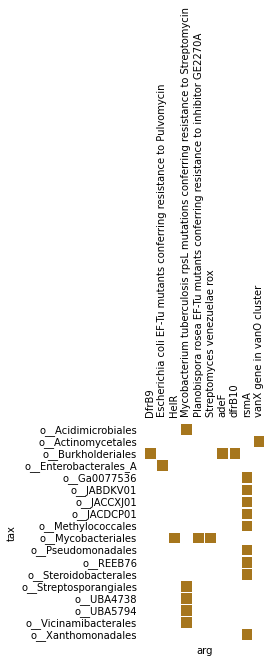

In [10]:
from matplotlib.colors import ListedColormap
fig, ax = plt.subplots()
cmap = ListedColormap(['#ffffff', '#a6761d'])
sns.heatmap(wide, cmap=cmap, cbar=False, square=True, linewidths=0.5)
ax.xaxis.tick_top()
ax.set_xticklabels(wide.columns,rotation=90)
ax.tick_params(left=False) 
ax.tick_params(top=False) 

In [11]:
df = pd.read_csv(r'../pre-calculated_data/mag_mean.tsv',sep='\t')
df

,Genome,Mean
0,cpsnj01_SemiBin_71,33.09549
1,cpsnj01_SemiBin_11,64.14305
2,cpsnj01_SemiBin_24,26.739128
3,cpsnj01_SemiBin_9,73.79866
4,cpsnj01_SemiBin_90,27.136549
...,...,...
8001,snj20_SemiBin_27,44.15666
8002,snj20_SemiBin_88,12.479121
8003,snj20_SemiBin_122,13.325371
8004,snj20_SemiBin_24,18.7069


In [12]:
merge_cov = pd.merge(merged,df,left_on='mag',right_on='Genome',how='inner')
merge_cov

,mag,gene,cutoff,arg,identity,aro,drug_class,mechanism,aro_family,seq,...,MIMAG,SGB,ARO,Drug Class,Resistance Mechanism,AMR Gene Family,GC content,tax,Genome,Mean
0,cpsnj03_SemiBin_14,cpsnj03_contig_484_polypolish_243 # 234053 # 2...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,82.64,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MPTIQQLVRQGRSRPREKTKAPALKGSPQRRGVCTRVYTTTPKKPN...,...,F,2724_5,3002972;3003395,"glycopeptide antibiotic,aminoglycoside antibiotic",antibiotic target alteration,"glycopeptide resistance gene cluster; vanT,ant...",0.706121,o__UBA4738,cpsnj03_SemiBin_14,33.177795
1,cpsnj03_SemiBin_18,cpsnj03_contig_24068_polypolish_420 # 471869 #...,Strict,rsmA,83.05,3005069,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,MLILTRRVGETVMIGDDVTVTVLGVKGNQVRIGVNAPKSVAVHREE...,...,F,2036_1,3000777;3005069,fluoroquinolone antibiotic; tetracycline antib...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,0.680293,o__Steroidobacterales,cpsnj03_SemiBin_18,29.74244
2,cpsnj03_SemiBin_36,cpsnj03_contig_4622_polypolish_246 # 237203 # ...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,86.99,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MPTIQQLVRQGRSSKSTKTKTPALKGSPQRRGVCTRVYTTTPKKPN...,...,F,2735_2,3002972;3003395,"glycopeptide antibiotic,aminoglycoside antibiotic",antibiotic target alteration,"glycopeptide resistance gene cluster; vanT,ant...",0.694048,o__Acidimicrobiales,cpsnj03_SemiBin_36,43.221725
3,cpsnj04_SemiBin_13,cpsnj04_contig_8_polypolish_469 # 488668 # 488...,Strict,rsmA,83.05,3005069,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,MLILTRRVGETVMIGDDVTVTVLGVKGNQVRIGVNAPKSVAVHREE...,...,F,2036_1,3000777;3005069,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,0.679432,o__Steroidobacterales,cpsnj04_SemiBin_13,24.98335
4,cpsnj04_SemiBin_48,cpsnj04_contig_81817_polypolish_54 # 38621 # 3...,Strict,rsmA,85.96,3005069,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,MLILTRRVGETLMIGDAITVTVLGVKGNQVRLGVNAPKEVAVHREE...,...,F,788_3,3005069;3007015;3004107,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic target alteration; antibiotic efflu...,ATP-binding cassette (ABC) antibiotic efflux p...,0.633799,o__Pseudomonadales,cpsnj04_SemiBin_48,12.532675
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,snj20_SemiBin_148,snj20_contig_7095_polypolish_208 # 184157 # 18...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,86.99,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MPTIQQLVRQGRSSKSTKTKTPALKGSPQRRGVCTRVYTTTPKKPN...,...,F,2735_2,3002972;3003395,"glycopeptide antibiotic,aminoglycoside antibiotic",antibiotic target alteration,"glycopeptide resistance gene cluster; vanT,ant...",0.689237,o__Acidimicrobiales,snj20_SemiBin_148,45.70175
129,snj20_SemiBin_58,snj20_contig_44448_polypolish_96 # 69795 # 702...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,86.18,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MHCPLTGVPSPVYGGRARLAQPTTFRRPWCRRSDQTNEVSFVPTIQ...,...,F,2732_0,3002972;3003395,"glycopeptide antibiotic,aminoglycoside antibiotic",antibiotic target alteration,"glycopeptide resistance gene cluster; vanT,ant...",0.691118,o__Acidimicrobiales,snj20_SemiBin_58,41.595436
130,snj20_SemiBin_60,snj20_contig_14416_polypolish_62 # 51252 # 526...,Strict,Streptomyces venezuelae rox,80.38,3007209,rifamycin antibiotic,antibiotic inactivation,rifampin monooxygenase,MFDVIIAGGGPTGMMLAGELRLHGVRVLVLEKEAEPTKVVRSLGLH...,...,F,2798_0,3003724;3007209,"glycopeptide antibiotic,rifamycin antibiotic","antibiotic target altera

<AxesSubplot:xlabel='Mean', ylabel='tax'>

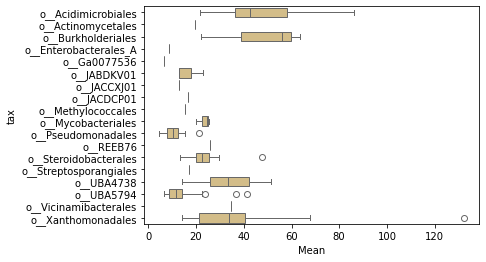

In [13]:
order=wide.index
merge_cov['Mean'] = pd.to_numeric(merge_cov['Mean'], errors='coerce')
sns.boxplot(merge_cov, x="Mean", y="tax",color='#dfc27d',order=order)

In [14]:
merged

,mag,gene,cutoff,arg,identity,aro,drug_class,mechanism,aro_family,seq,...,Unique tRNA,GTDB,MIMAG,SGB,ARO,Drug Class,Resistance Mechanism,AMR Gene Family,GC content,tax
0,cpsnj03_SemiBin_14,cpsnj03_contig_484_polypolish_243 # 234053 # 2...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,82.64,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MPTIQQLVRQGRSRPREKTKAPALKGSPQRRGVCTRVYTTTPKKPN...,...,19,d__Bacteria;p__Actinomycetota;c__UBA4738;o__UB...,F,2724_5,3002972;3003395,"glycopeptide antibiotic,aminoglycoside antibiotic",antibiotic target alteration,"glycopeptide resistance gene cluster; vanT,ant...",0.706121,o__UBA4738
1,cpsnj03_SemiBin_18,cpsnj03_contig_24068_polypolish_420 # 471869 #...,Strict,rsmA,83.05,3005069,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,MLILTRRVGETVMIGDDVTVTVLGVKGNQVRIGVNAPKSVAVHREE...,...,20,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,F,2036_1,3000777;3005069,fluoroquinolone antibiotic; tetracycline antib...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,0.680293,o__Steroidobacterales
2,cpsnj03_SemiBin_36,cpsnj03_contig_4622_polypolish_246 # 237203 # ...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,86.99,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MPTIQQLVRQGRSSKSTKTKTPALKGSPQRRGVCTRVYTTTPKKPN...,...,19,d__Bacteria;p__Actinomycetota;c__Acidimicrobii...,F,2735_2,3002972;3003395,"glycopeptide antibiotic,aminoglycoside antibiotic",antibiotic target alteration,"glycopeptide resistance gene cluster; vanT,ant...",0.694048,o__Acidimicrobiales
3,cpsnj04_SemiBin_13,cpsnj04_contig_8_polypolish_469 # 488668 # 488...,Strict,rsmA,83.05,3005069,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,MLILTRRVGETVMIGDDVTVTVLGVKGNQVRIGVNAPKSVAVHREE...,...,20,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,F,2036_1,3000777;3005069,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,0.679432,o__Steroidobacterales
4,cpsnj04_SemiBin_48,cpsnj04_contig_81817_polypolish_54 # 38621 # 3...,Strict,rsmA,85.96,3005069,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,MLILTRRVGETLMIGDAITVTVLGVKGNQVRLGVNAPKEVAVHREE...,...,20,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,F,788_3,3005069;3007015;3004107,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic target alteration; antibiotic efflu...,ATP-binding cassette (ABC) antibiotic efflux p...,0.633799,o__Pseudomonadales
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,snj20_SemiBin_148,snj20_contig_7095_polypolish_208 # 184157 # 18...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,86.99,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MPTIQQLVRQGRSSKSTKTKTPALKGSPQRRGVCTRVYTTTPKKPN...,...,18,d__Bacteria;p__Actinomycetota;c__Acidimicrobii...,F,2735_2,3002972;3003395,"glycopeptide antibiotic,aminoglycoside antibiotic",antibiotic target alteration,"glycopeptide resistance gene cluster; vanT,ant...",0.689237,o__Acidimicrobiales
129,snj20_SemiBin_58,snj20_contig_44448_polypolish_96 # 69795 # 702...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,86.18,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MHCPLTGVPSPVYGGRARLAQPTTFRRPWCRRSDQTNEVSFVPTIQ...,...,18,d__Bacteria;p__Actinomycetota;c__Acidimicrobii...,F,2732_0,3002972;3003395,"glycopeptide antibiotic,aminoglycoside antibiotic",antibiotic target alteration,"glycopeptide resistance gene cluster; vanT,ant...",0.691118,o__Acidimicrobiales
130,snj20_SemiBin_60,snj20_contig_14416_polypolish_62 # 51252 # 526...,Strict,Streptomyces venezuelae rox,80.38,3007209,rifamycin antibiotic,antibiotic inactiva

In [15]:
df = pd.read_csv(r'../pre-calculated_data/mags_dedup_rgi_80.tsv',sep='\t',usecols=[2,7,10,11,12,16,17,18,20,22],names=['gene','cutoff','arg','identity','aro','drug_class','mechanism','aro_family','seq','coverage'])
df

,gene,cutoff,arg,identity,aro,drug_class,mechanism,aro_family,seq,coverage
0,cpsnj03_contig_484_polypolish_243 # 234053 # 2...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,82.64,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MPTIQQLVRQGRSRPREKTKAPALKGSPQRRGVCTRVYTTTPKKPN...,100.00
1,cpsnj03_contig_24068_polypolish_420 # 471869 #...,Strict,rsmA,83.05,3005069,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,MLILTRRVGETVMIGDDVTVTVLGVKGNQVRIGVNAPKSVAVHREE...,113.11
2,cpsnj03_contig_4622_polypolish_246 # 237203 # ...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,86.99,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MPTIQQLVRQGRSSKSTKTKTPALKGSPQRRGVCTRVYTTTPKKPN...,99.19
3,cpsnj04_contig_81817_polypolish_54 # 38621 # 3...,Strict,rsmA,85.96,3005069,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,MLILTRRVGETLMIGDAITVTVLGVKGNQVRLGVNAPKEVAVHREE...,108.20
4,cpsnj08_contig_62247_polypolish_216 # 189749 #...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,87.80,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MPTIQQLVRKGRSTKSTKSKTPALKGSPQRRGVCTRVYTTTPKKPN...,99.19
...,...,...,...,...,...,...,...,...,...,...
77,snj15_contig_48596_polypolish_14 # 8603 # 9937...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,86.89,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MRTFHTGGVAGKDIAGGLPRVVELFEARTPRGSARLARATGVVRIG...,358.06
78,snj15_contig_22732_polypolish_342 # 244034 # 2...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,81.15,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MPTIEQLVREGRQPKLKKAKTAALAGAPQRRGVCTRVYTVTPKKPN...,100.00
79,snj15_contig_79093_polypolish_119 # 89706 # 89...,Strict,rsmA,80.65,3005069,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,MLILTRRCAESLIIGDGEITVTVLGVKGNQVRIGVNAPKEVAVHRE...,101.64
80,snj20_contig_44448_polypolish_96 # 69795 # 702...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,86.18,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MHCPLTGVPSPVYGGRARLAQPTTFRRPWCRRSDQTNEVSFVPTIQ...,132.26


In [16]:
drug_class_mag = df['drug_class'].value_counts(normalize=True)
drug_class_mag

drug_class
aminoglycoside antibiotic                                                        0.475610
fluoroquinolone antibiotic; diaminopyrimidine antibiotic; phenicol antibiotic    0.414634
elfamycin antibiotic                                                             0.036585
diaminopyrimidine antibiotic                                                     0.024390
rifamycin antibiotic                                                             0.024390
fluoroquinolone antibiotic; tetracycline antibiotic                              0.012195
glycopeptide antibiotic                                                          0.012195
Name: proportion, dtype: float64

In [17]:
expanded_classes = df['drug_class'].str.split(';').apply(lambda x: [i.strip() for i in x]).explode()
class_counts = expanded_classes.value_counts()
total_count = expanded_classes.count()
class_proportions = class_counts / total_count
drug_mag = pd.DataFrame({
    'mag_count': class_counts,
    'mag_proportion': class_proportions
})
drug_mag = drug_mag.reset_index().rename(columns={'index': 'drug_class'})
drug_mag

,drug_class,mag_count,mag_proportion
0,aminoglycoside antibiotic,39,0.258278
1,diaminopyrimidine antibiotic,36,0.238411
2,fluoroquinolone antibiotic,35,0.231788
3,phenicol antibiotic,34,0.225166
4,elfamycin antibiotic,3,0.019868
5,rifamycin antibiotic,2,0.013245
6,tetracycline antibiotic,1,0.006623
7,glycopeptide antibiotic,1,0.006623


In [18]:
mec_mag = df['mechanism'].value_counts(normalize=True)
mec_mag

mechanism
antibiotic target alteration     0.524390
antibiotic efflux                0.426829
antibiotic target replacement    0.024390
antibiotic target protection     0.012195
antibiotic inactivation          0.012195
Name: proportion, dtype: float64

In [19]:
expanded_classes = df['mechanism'].str.split(';').apply(lambda x: [i.strip() for i in x]).explode()
class_counts = expanded_classes.value_counts()
total_count = expanded_classes.count()
class_proportions = class_counts / total_count
mechanism_mag = pd.DataFrame({
    'mag_count': class_counts,
    'mag_proportion': class_proportions
})
mechanism_mag=mechanism_mag.reset_index().rename(columns={'index': 'mechanism'})
mechanism_mag

,mechanism,mag_count,mag_proportion
0,antibiotic target alteration,43,0.524390
1,antibiotic efflux,35,0.426829
2,antibiotic target replacement,2,0.024390
3,antibiotic target protection,1,0.012195
4,antibiotic inactivation,1,0.012195


In [22]:
df = pd.read_csv(r'../pre-calculated_data/contig_rgi_pf_st_dedup.tsv.gz',compression='gzip',sep='\t',usecols=[0,5,8,9,10,14,15,16,18,20],names=['gene','cutoff','arg','identity','aro','drug_class','mechanism','aro_family','seq','coverage'])
df

,gene,cutoff,arg,identity,aro,drug_class,mechanism,aro_family,seq,coverage
0,cpsnj02_contig_19095_polypolish_66 # 35345 # 3...,Perfect,abeS,100.00,3000768,macrolide antibiotic; aminocoumarin antibiotic,antibiotic efflux,small multidrug resistance (SMR) antibiotic ef...,MSYLYLAIAIACEVIATSALKASQGFTVPIPSIITVVGYAVAFYLL...,100.00
1,cpsnj02_contig_63167_polypolish_4 # 1615 # 247...,Perfect,TEM-116,100.00,3000979,monobactam; cephalosporin; penam; penem,antibiotic inactivation,TEM beta-lactamase,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,100.00
2,cpsnj20_contig_27086_polypolish_27 # 25284 # 2...,Perfect,sul2,100.00,3000412,sulfonamide antibiotic,antibiotic target replacement,sulfonamide resistant sul,MNKSLIIFGIVNITSDSFSDGGRYLAPDAAIAQARKLMAEGADVID...,100.00
3,cpsnj01_contig_229_polypolish_126 # 124507 # 1...,Strict,qacG,42.31,3007015,disinfecting agents and antiseptics,antibiotic efflux,small multidrug resistance (SMR) antibiotic ef...,MNIGYLYLAIAIVAEVAATSALKASEGFTRPGPSLIVVAGYGLAFY...,103.74
4,cpsnj01_contig_22073_polypolish_17 # 9777 # 11...,Strict,vanW gene in vanI cluster,30.86,3003724,glycopeptide antibiotic,antibiotic target alteration,vanW; glycopeptide resistance gene cluster,MDTLLDQPLDAEPVPALVGVAGRQVRLQLLDERGGIGRVRAFPVDL...,191.42
...,...,...,...,...,...,...,...,...,...,...
30301,snj20_contig_13040_polypolish_16 # 14652 # 156...,Strict,vanT gene in vanG cluster,34.41,3002972,glycopeptide antibiotic,antibiotic target alteration,glycopeptide resistance gene cluster; vanT,MSFSKDQENILARRPTWAEIDLNHLAANFKRIKQRVGPVARVMAVV...,46.77
30302,snj20_contig_88292_polypolish_45 # 37911 # 410...,Strict,adeF,67.09,3000777,fluoroquinolone antibiotic; tetracycline antib...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,MRILPIAEYPEVVPPEVVVNAIYPGANPRVIGETVATPLEEQINGV...,97.73
30303,snj20_contig_66299_polypolish_28 # 20369 # 211...,Strict,vanY gene in vanM cluster,33.09,3002961,glycopeptide antibiotic,antibiotic target alteration,vanY; glycopeptide resistance gene cluster,MRSVARVLINTPDIELWPGGLLRARSNHDQRILSRATRVLRRKTDG...,114.59
30304,snj20_contig_40146_polypolish_4 # 873 # 1508 #...,Strict,vanY gene in vanB cluster,31.54,3002956,glycopeptide antibiotic,antibiotic target alteration,vanY; glycopeptide resistance gene cluster,MIVAESARSRAGKAFVRVCRAEIKRGKIKAKEELGWTAAANLTEGC...,78.73


In [23]:
df['identity'] = pd.to_numeric(df['identity'], errors='coerce')
df['coverage'] = pd.to_numeric(df['coverage'], errors='coerce')
df= df[(df['identity']>80) & (df['coverage']>90)]
df

,gene,cutoff,arg,identity,aro,drug_class,mechanism,aro_family,seq,coverage
0,cpsnj02_contig_19095_polypolish_66 # 35345 # 3...,Perfect,abeS,100.00,3000768,macrolide antibiotic; aminocoumarin antibiotic,antibiotic efflux,small multidrug resistance (SMR) antibiotic ef...,MSYLYLAIAIACEVIATSALKASQGFTVPIPSIITVVGYAVAFYLL...,100.00
1,cpsnj02_contig_63167_polypolish_4 # 1615 # 247...,Perfect,TEM-116,100.00,3000979,monobactam; cephalosporin; penam; penem,antibiotic inactivation,TEM beta-lactamase,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,100.00
2,cpsnj20_contig_27086_polypolish_27 # 25284 # 2...,Perfect,sul2,100.00,3000412,sulfonamide antibiotic,antibiotic target replacement,sulfonamide resistant sul,MNKSLIIFGIVNITSDSFSDGGRYLAPDAAIAQARKLMAEGADVID...,100.00
36,cpsnj01_contig_47006_polypolish_24 # 19386 # 1...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,86.99,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MPTIQQLVRQGRSSKSTKTKTPALKGSPQRRGVCTRVYTTTPKKPN...,99.19
41,cpsnj01_contig_62146_polypolish_4 # 3085 # 345...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,86.18,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MPTIQQLVRQGRSSKVTKSKTPALKGSPQRRGVCTRVYTTTPKKPN...,99.19
...,...,...,...,...,...,...,...,...,...,...
30100,snj20_contig_75234_polypolish_29 # 25420 # 257...,Strict,Mycobacterium tuberculosis rpsL mutations conf...,87.80,3003395,aminoglycoside antibiotic,antibiotic target alteration,antibiotic-resistant rpsL,MPTIQQLVRKGRSTKTTKSKTPALKGSPQRRGVCTRVYTTTPKKPN...,99.19
30111,snj20_contig_65702_polypolish_61 # 57789 # 580...,Strict,rsmA,84.48,3005069,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,MLILTRRVGETLMIGDSVTVTVLGVKGNQVRIGINAPKDVAVHREE...,131.15
30128,snj20_contig_7248_polypolish_13 # 11407 # 1169...,Strict,rsmA,88.89,3005069,fluoroquinolone antibiotic; diaminopyrimidine ...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,MLILTRRVGETLMIGDSVTVTVLGVKGNQVRIGITAPKDVAVHREE...,155.74
30131,snj20_contig_10398_polypolish_67 # 58101 # 590...,Strict,CRD3-1,94.06,3006864,carbapenem,antibiotic inactivation,CRD3 beta-lactamase,MFASLIAVALAAQQIIVPLGKTPRQIERPRAPIETAGPQWAAACGD...,100.00


In [24]:
expanded_classes = df['drug_class'].str.split(';').apply(lambda x: [i.strip() for i in x]).explode()
class_counts = expanded_classes.value_counts()
total_count = expanded_classes.count()
class_proportions = class_counts / total_count
drug_contig = pd.DataFrame({
    'contig_count': class_counts,
    'contig_proportion': class_proportions
})
drug_contig=drug_contig.reset_index().rename(columns={'index': 'drug_class'})
drug_contig

,drug_class,contig_count,contig_proportion
0,aminoglycoside antibiotic,199,0.285100
1,diaminopyrimidine antibiotic,150,0.214900
2,fluoroquinolone antibiotic,140,0.200573
3,phenicol antibiotic,136,0.194842
4,rifamycin antibiotic,13,0.018625
5,carbapenem,11,0.015759
6,penam,8,0.011461
7,tetracycline antibiotic,8,0.011461
8,cephalosporin,7,0.010029
9,glycylcycline,4,0.005731


In [28]:
drug_class_contig =df['drug_class'].value_counts(normalize=True)
drug_class_contig

drug_class
aminoglycoside antibiotic                                                                                                                                                                                              0.512887
fluoroquinolone antibiotic; diaminopyrimidine antibiotic; phenicol antibiotic                                                                                                                                          0.337629
diaminopyrimidine antibiotic                                                                                                                                                                                           0.048969
rifamycin antibiotic                                                                                                                                                                                                   0.023196
carbapenem                                                                                   

In [29]:
mec_contig = df['mechanism'].value_counts(normalize=True)
mec_contig

mechanism
antibiotic target alteration                                                           0.523196
antibiotic efflux                                                                      0.358247
antibiotic inactivation                                                                0.051546
antibiotic target replacement                                                          0.051546
antibiotic target protection                                                           0.005155
antibiotic target alteration; antibiotic efflux                                        0.005155
antibiotic target alteration; antibiotic efflux; reduced permeability to antibiotic    0.002577
antibiotic efflux; reduced permeability to antibiotic                                  0.002577
Name: proportion, dtype: float64

In [30]:
expanded_classes = df['mechanism'].str.split(';').apply(lambda x: [i.strip() for i in x]).explode()
class_counts = expanded_classes.value_counts()
total_count = expanded_classes.count()
class_proportions = class_counts / total_count
mec_contig = pd.DataFrame({
    'contig_count': class_counts,
    'contig_proportion': class_proportions
})
mec_contig=mec_contig.reset_index().rename(columns={'index': 'mechanism'})
mec_contig

,mechanism,contig_count,contig_proportion
0,antibiotic target alteration,206,0.524173
1,antibiotic efflux,143,0.363868
2,antibiotic inactivation,20,0.050891
3,antibiotic target replacement,20,0.050891
4,antibiotic target protection,2,0.005089
5,reduced permeability to antibiotic,2,0.005089


In [31]:
mec_merge = pd.merge(mechanism_mag,mec_contig,on='mechanism',how='outer')
mec_merge = mec_merge.fillna(0)

In [32]:
drug_merge = pd.merge(drug_mag,drug_contig,on='drug_class',how='outer')
drug_merge = drug_merge.fillna(0)

In [33]:
mec = mec_merge[['mechanism','mag_count','contig_count']]
mec = mec.set_index('mechanism')
mec = mec.sort_values(by='contig_count', ascending=True)
mec

,mag_count,contig_count
mechanism,,
antibiotic target protection,1.0,2
reduced permeability to antibiotic,0.0,2
antibiotic target replacement,2.0,20
antibiotic inactivation,1.0,20
antibiotic efflux,35.0,143
antibiotic target alteration,43.0,206


In [34]:
mec_stack = mec.stack() 
mec_stack.index = mec_stack.index.rename('type',level=1)
mec_stack.name = 'Count'
mec_stack = mec_stack.reset_index() 
mec_stack

,mechanism,type,Count
0,antibiotic target protection,mag_count,1.0
1,antibiotic target protection,contig_count,2.0
2,reduced permeability to antibiotic,mag_count,0.0
3,reduced permeability to antibiotic,contig_count,2.0
4,antibiotic target replacement,mag_count,2.0
5,antibiotic target replacement,contig_count,20.0
6,antibiotic inactivation,mag_count,1.0
7,antibiotic inactivation,contig_count,20.0
8,antibiotic efflux,mag_count,35.0
9,antibiotic efflux,contig_count,143.0


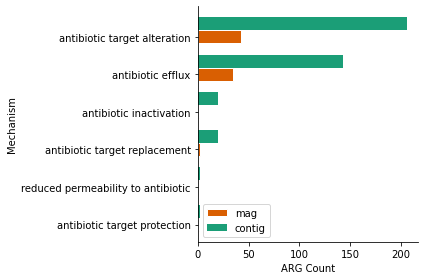

In [47]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()

x1 = np.arange(6)
y = mec_stack[mec_stack['type'] == 'mag_count']['Count'].tolist()
y1 = mec_stack[mec_stack['type'] == 'contig_count']['Count'].tolist()

bar_width = 0.35

ticks = range(6)
tick_label = mec_stack[mec_stack['type'] == 'mag_count']['mechanism'].tolist()
plt.yticks(ticks, tick_label)

plt.barh(x1, y, bar_width, color='#d95f02', align='center', label='mag', edgecolor='white')
plt.barh(x1 + bar_width, y1, bar_width, color='#1b9e77', align='center', label="contig")

plt.legend()

ax.set_ylabel('Mechanism')
ax.set_xlabel('ARG Count')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(r'D:\soil\manuscript\draft\mine\ARG_mechanism.svg')

In [48]:
drug = drug_merge[['drug_class','mag_count','contig_count']]
drug = drug.set_index('drug_class')
drug = drug.sort_values(by='contig_count', ascending=True)
drug = drug.tail(10)
drug

,mag_count,contig_count
drug_class,,
disinfecting agents and antiseptics,0.0,4.0
cephalosporin,0.0,7.0
tetracycline antibiotic,1.0,8.0
penam,0.0,8.0
carbapenem,0.0,11.0
rifamycin antibiotic,2.0,13.0
phenicol antibiotic,34.0,136.0
fluoroquinolone antibiotic,35.0,140.0
diaminopyrimidine antibiotic,36.0,150.0


In [49]:
drug_stack = drug.stack() 
drug_stack.index = drug_stack.index.rename('type',level=1)
drug_stack.name = 'Count'
drug_stack = drug_stack.reset_index() 
drug_stack

,drug_class,type,Count
0,disinfecting agents and antiseptics,mag_count,0.0
1,disinfecting agents and antiseptics,contig_count,4.0
2,cephalosporin,mag_count,0.0
3,cephalosporin,contig_count,7.0
4,tetracycline antibiotic,mag_count,1.0
5,tetracycline antibiotic,contig_count,8.0
6,penam,mag_count,0.0
7,penam,contig_count,8.0
8,carbapenem,mag_count,0.0
9,carbapenem,contig_count,11.0


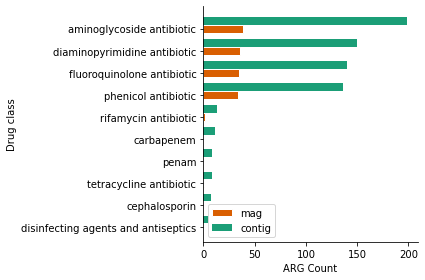

In [51]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()

x1 = np.arange(10)
y = drug_stack[drug_stack['type'] == 'mag_count']['Count'].tolist()
y1 = drug_stack[drug_stack['type'] == 'contig_count']['Count'].tolist()

bar_width = 0.35

ticks = range(10)
tick_label = drug_stack[drug_stack['type'] == 'mag_count']['drug_class'].tolist()
plt.yticks(ticks, tick_label)

plt.barh(x1, y, bar_width, color='#d95f02', align='center', label='mag', edgecolor='white')
plt.barh(x1 + bar_width, y1, bar_width, color='#1b9e77', align='center', label="contig")

plt.legend()

ax.set_ylabel('Drug class')
ax.set_xlabel('ARG Count')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(r'D:\soil\manuscript\draft\mine\ARG_drug_class.svg')